In [17]:
import pandas as pd
import glob
import numpy as np
import json
import matplotlib.pyplot as plt

In [51]:
files = np.array(glob.glob("dump_*_recov.json"))
recov = np.array([float(f.split('_')[1]) for f in files])
args = np.argsort(recov)
files = files[args]

In [175]:
data = []
for fi in files:
    with open(fi) as f:
        js = json.load(f)

    d = {
        key: js[key] 
        for key in [
            'SEC', 
            'LCOW', 
            'WaterTAP LCOW', 
            'Recovery', 
            'Fixed OM Cost', 
            'Variable OM Cost',
            'Permeate Flow',
            'Annualized Cost'
        ]
    }

    data.append(d)

df_lsrro = pd.DataFrame(data)
df_lsrro = df_lsrro.set_index('Recovery')
df_lsrro

,SEC,LCOW,WaterTAP LCOW,Fixed OM Cost,Variable OM Cost,Permeate Flow,Annualized Cost
Recovery,,,,,,,
0.20,19.155976,6.808468,6.298307,1485.746976,298.349395,0.003054,0.656179
0.30,16.604565,5.334900,4.467245,1485.774764,298.354953,0.004581,0.771242
0.40,16.575300,4.982133,3.638965,1485.822409,298.364482,0.006108,0.960325
0.45,17.706272,5.237361,3.442723,1485.867750,298.373550,0.006872,1.135711
0.50,21.163754,6.240422,3.464418,1485.961252,298.392250,0.007635,1.503581


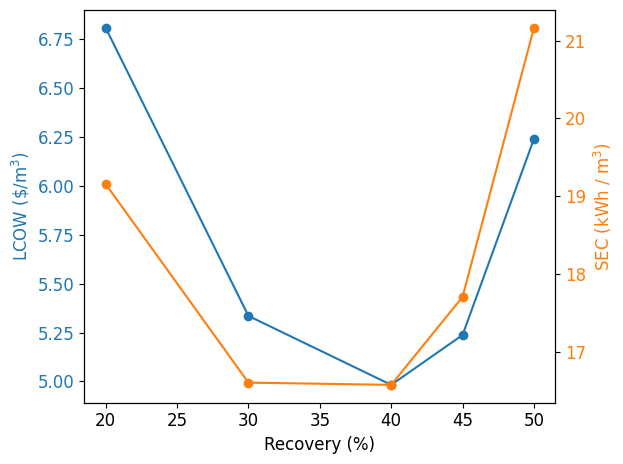

In [160]:
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots()
lcow_label = 'LCOW (\$/m$^3$)'
sec_label = 'SEC (kWh / m$^3$)'
color = 'tab:blue'
ax1.plot(df_lsrro['Recovery']*100, df_lsrro['LCOW'], '-o', color=color)
ax1.set_xlabel('Recovery (%)')
ax1.set_ylabel('LCOW (\$/m$^3$)', color=color)
ax1.tick_params(axis='y', labelcolor=color)

color = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(df_lsrro['Recovery']*100, df_lsrro['SEC'], '-o', color=color)
ax2.set_ylabel(sec_label, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.tight_layout()

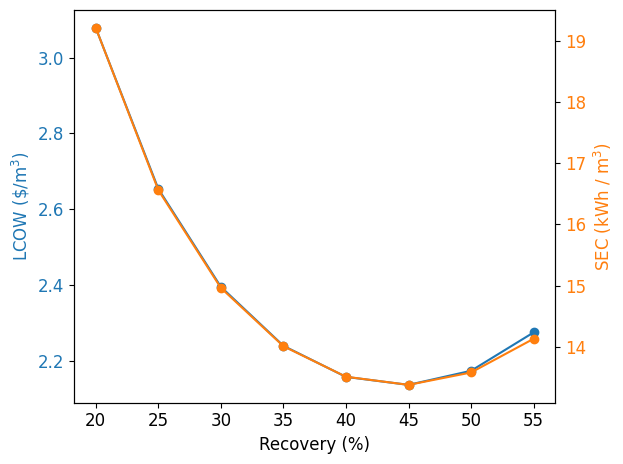

In [171]:
with open('../Train0/results_fixed_recovery.json', 'r') as f:
    data = json.load(f)
df_ro = pd.DataFrame.from_dict(data, orient='index')
df_ro.index = df_ro.index.astype(float).round(2)
df_ro.index.name = 'Recovery'

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.plot(df_ro['Recovery']*100, df_ro['LCOW'], '-o', color=color)
ax1.set_xlabel('Recovery (%)')
ax1.set_ylabel('LCOW (\$/m$^3$)', color=color)
ax1.tick_params(axis='y', labelcolor=color)

color = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(df_ro['Recovery']*100, df_ro['SEC'], '-o', color=color)
ax2.set_ylabel(sec_label, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.tight_layout()

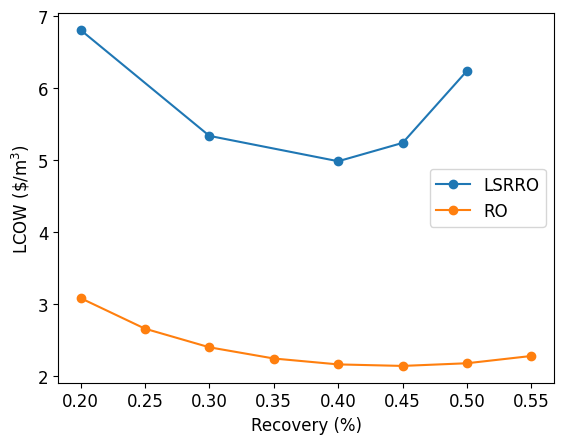

In [162]:
plt.plot(df_lsrro['Recovery'], df_lsrro['LCOW'], '-o', label='LSRRO')
plt.plot(df_ro['Recovery'], df_ro['LCOW'], '-o', label='RO')
plt.xlabel('Recovery (%)')
plt.ylabel(lcow_label)
plt.legend()

Text(0, 0.5, 'SEC (kWh / m$^3$)')

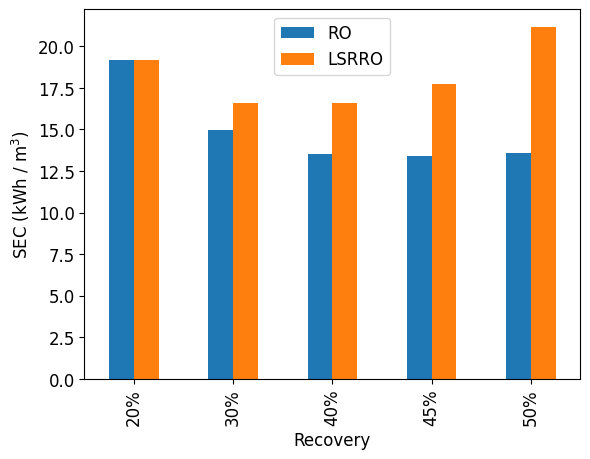

In [182]:
# Then create new dataframe with overlapping indices only
common_indices = df_ro.index.intersection(df_lsrro.index)

pd.DataFrame({
    'RO': df_ro.loc[common_indices]['SEC'],
    'LSRRO': df_lsrro.loc[common_indices]['SEC']
}).plot.bar()
plt.xticks(range(len(common_indices)), [f'{x*100:.0f}%' for x in common_indices])
plt.ylabel(sec_label)

